#  ₦ Importation & Exploration

In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 

### Lire le fichier bank_transactions.csv et afficher les informations du data

In [112]:
#charger les donnees
df=pd.read_csv("bank.csv")
#afficher les 5 premiers lignes
df.head()

,transaction_id,client_id,date_transaction,montant,devise,taux_change_eur,montant_eur,categorie,produit,agence,type_operation,statut,score_credit_client,segment_client,solde_avant,taux_interet
0,TXN000559,CLI0060,2022-04-19 02:31:00,2050.42,EUR,1.00,2050.42,Depot especes,Compte Epargne,Marseille-Vieux-Port,Credit,Complete,NaN,Premium,16415.1,NaN
1,TXN001154,CLI0057,2024-06-20 20:51:00,-123.66,GBP,0.86,-143.79,Retrait DAB,Credit Consommation,NaN,Debit,Rejete,435.0,Risque,42890.81,NaN
2,TXN000764,CLI0015,2024-08-28 05:03:00,-396.17,EUR,1.00,-396.17,Prelevement,PEA,Lyon-Part-Dieu,Debit,Complete,648.0,Standard,48489.38,NaN
3,TXN001598,CLI0045,2024-01-07 08:16:00,225.2,EUR,1.00,225.20,Paiement CB,Credit Consommation,Bordeaux-Meriadeck,Credit,Complete,704.0,Standard,43962.51,NaN
4,TXN001873,CLI0034,2024-08-11 19:52:00,935.32,EUR,1.00,935.32,Interets,Credit Immobilier,Bordeaux-Meriadeck,Credit,Complete,457.0,Risque,17312.83,NaN


In [113]:
#afficher les dimensions
print("les dimensions:\n",df.shape)
#afficher les statistiques du data
print("\n les statistiques : \n",df.describe())
#afficher le type des colonnes
print("\nles types des colonnes: \n",df.dtypes)


les dimensions:
 (2060, 16)

 les statistiques : 
        taux_change_eur  montant_eur  score_credit_client  taux_interet
count      2060.000000  2060.000000          1893.000000           0.0
mean          1.534782  -116.223170           627.866350           NaN
std           2.234708  2083.777234           132.193879           NaN
min           0.860000 -8705.810000          -100.000000           NaN
25%           1.000000 -1218.870000           586.000000           NaN
50%           1.000000   -60.405000           643.000000           NaN
75%           1.000000   957.805000           701.000000           NaN
max          10.850000  9026.940000          1500.000000           NaN

les types des colonnes: 
 transaction_id             str
client_id                  str
date_transaction           str
montant                    str
devise                     str
taux_change_eur        float64
montant_eur            float64
categorie                  str
produit                    str
agen

### Identifier toutes les colonnes problématiques : types incorrects, formats mixtes, valeurs suspectes

In [114]:
#afficher les informations sur  data
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2060 entries, 0 to 2059
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       2060 non-null   str    
 1   client_id            2060 non-null   str    
 2   date_transaction     2060 non-null   str    
 3   montant              2060 non-null   str    
 4   devise               2060 non-null   str    
 5   taux_change_eur      2060 non-null   float64
 6   montant_eur          2060 non-null   float64
 7   categorie            2060 non-null   str    
 8   produit              2060 non-null   str    
 9   agence               1996 non-null   str    
 10  type_operation       2060 non-null   str    
 11  statut               2060 non-null   str    
 12  score_credit_client  1893 non-null   float64
 13  segment_client       1955 non-null   str    
 14  solde_avant          2060 non-null   str    
 15  taux_interet         0 non-null      float64
dtyp

In [115]:
#Detection Formats mixtes / incohérences
for col in df.select_dtypes(include="object"):
    print(col, df[col].nunique())
    


transaction_id 2000
client_id 150
date_transaction 2058
montant 1974
devise 9
categorie 8
produit 8
agence 16
type_operation 2
statut 3
segment_client 6
solde_avant 2000


C:\Users\nouha\AppData\Local\Temp\ipykernel_15552\3487122985.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object"):


### Taux de valeurs manquantes

In [116]:
vl_manq_taux=df.isnull().mean()*100
print("\n taux de valeurs manquantes: ",vl_manq_taux)


 taux de valeurs manquantes:  transaction_id           0.000000
client_id                0.000000
date_transaction         0.000000
montant                  0.000000
devise                   0.000000
taux_change_eur          0.000000
montant_eur              0.000000
categorie                0.000000
produit                  0.000000
agence                   3.106796
type_operation           0.000000
statut                   0.000000
score_credit_client      8.106796
segment_client           5.097087
solde_avant              0.000000
taux_interet           100.000000
dtype: float64


### visualiser la distribution

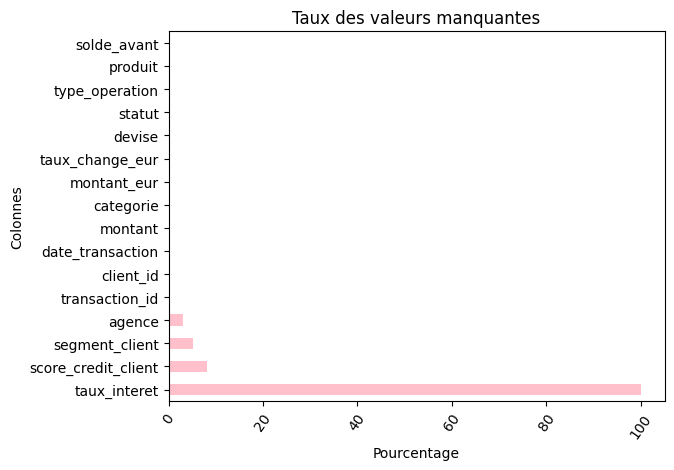

In [117]:
vl_manq_taux.sort_values(ascending=False).plot(kind="barh",color='pink')
plt.title("Taux des valeurs manquantes")
plt.xlabel("Pourcentage")
plt.ylabel("Colonnes")
plt.xticks(rotation=55)
plt.show()

### Repérer les doublons avec transaction_id 

In [118]:
duplicates=df[df.duplicated(subset="transaction_id",keep=False)]
print("Nombre des doublons: ",duplicates.shape[0])
print(duplicates.head())

Nombre des doublons:  120
   transaction_id client_id     date_transaction   montant devise  \
3       TXN001598   CLI0045  2024-01-07 08:16:00     225.2    EUR   
7       TXN000620   CLI0005     11/05/2022 08:57   1962.49    EUR   
14      TXN000116   CLI0077  2024-11-09 17:31:03  -5728.17    EUR   
21      TXN001448   CLI0141  2023-12-07 13:40:03  99999.99    EUR   
39      TXN001817   CLI0036  2022-08-25 16:20:00   4016.18    EUR   

    taux_change_eur  montant_eur               categorie              produit  \
3               1.0       225.20             Paiement CB  Credit Consommation   
7               1.0      1962.49    Remboursement credit             Livret A   
14              1.0     -5728.17  Virement international       Compte Courant   
21              1.0       264.77    Remboursement credit       Compte Courant   
39              1.0      4016.18  Virement international          Credit Auto   

                  agence type_operation    statut  score_credit_client  

### analyser les écarts de date

In [119]:
duplicates["date_transaction"] = pd.to_datetime(
    duplicates["date_transaction"], 
    errors="coerce"
)
duplicates=duplicates.sort_values(by=["transaction_id","date_transaction"])
duplicates["diff_date"]=duplicates.groupby("transaction_id")["date_transaction"].diff()
print(duplicates[["transaction_id","date_transaction","diff_date"]])

     transaction_id    date_transaction       diff_date
750       TXN000034 2024-02-21 18:22:00             NaT
1379      TXN000034 2024-02-21 18:22:03 0 days 00:00:03
394       TXN000052 2024-05-31 03:50:03             NaT
1128      TXN000052                 NaT             NaT
112       TXN000116 2024-11-09 17:31:00             NaT
...             ...                 ...             ...
1889      TXN001890 2022-10-31 22:03:03 0 days 00:00:03
1911      TXN001961 2023-05-03 19:02:00             NaT
1938      TXN001961 2023-05-03 19:02:03 0 days 00:00:03
1137      TXN001990 2024-05-21 21:09:00             NaT
1720      TXN001990 2024-05-21 21:09:03 0 days 00:00:03

[120 rows x 3 columns]


# ₦ Nettoyage des données

### Supprimer les doublons : conserver la première occurrence par transaction_id

In [120]:
df= df.drop_duplicates(subset="transaction_id",keep='first')
print(df.shape)

(2000, 16)


### Corriger les types de dates : unifier au format AAAA-MM-JJ HH:MM:SS

In [121]:
df["date_transaction"] = pd.to_datetime(
    df["date_transaction"],
    errors="coerce"
)

# Uniformiser le format
df["date_transaction"] = df["date_transaction"].dt.strftime("%Y-%m-%d %H:%M:%S")
df['date_transaction']

print(df.dtypes)

transaction_id             str
client_id                  str
date_transaction           str
montant                    str
devise                     str
taux_change_eur        float64
montant_eur            float64
categorie                  str
produit                    str
agence                     str
type_operation             str
statut                     str
score_credit_client    float64
segment_client             str
solde_avant                str
taux_interet           float64
dtype: object


###  Corriger les montants : remplacer les virgules par des points, convertir en float

In [122]:
df['montant']=df['montant'].str.replace(",",".")
df['montant']=pd.to_numeric(df['montant'],errors='coerce')

### Nettoyer la colonne solde_avant : supprimer le suffixe texte ' EUR', convertir en float

In [123]:
df['solde_avant']=df['solde_avant'].str.replace("EUR"," ").str.replace(',','.')

df['solde_avant']=pd.to_numeric(df['solde_avant'],errors='coerce')

### Normaliser les devises : passer en majuscules (eur → EUR)

In [124]:
df['devise']=df['devise'].str.upper()


### Harmoniser segment_client : unifier la casse (PREMIUM → Premium)

In [125]:
df['segment_client']=df['segment_client'].str.capitalize()

### Supprimer les espaces parasites sur la colonne agence

In [126]:
df['agence']=df['agence'].str.strip()

### Traiter les valeurs manquantes 

In [127]:
###Colonnes numériques 
num_cols = df.select_dtypes(include="float64").columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

#### Colonnes catégorielles
cat_cols = df.select_dtypes(include="string").columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [128]:
df.info()

<class 'pandas.DataFrame'>
Index: 2000 entries, 0 to 2059
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       2000 non-null   str    
 1   client_id            2000 non-null   str    
 2   date_transaction     2000 non-null   str    
 3   montant              2000 non-null   float64
 4   devise               2000 non-null   str    
 5   taux_change_eur      2000 non-null   float64
 6   montant_eur          2000 non-null   float64
 7   categorie            2000 non-null   str    
 8   produit              2000 non-null   str    
 9   agence               2000 non-null   str    
 10  type_operation       2000 non-null   str    
 11  statut               2000 non-null   str    
 12  score_credit_client  2000 non-null   float64
 13  segment_client       2000 non-null   str    
 14  solde_avant          2000 non-null   float64
 15  taux_interet         0 non-null      float64
dtypes: f

# ₦ Détection & Traitement des Valeurs Aberrantes

np.float64(-0.5542064802578116)

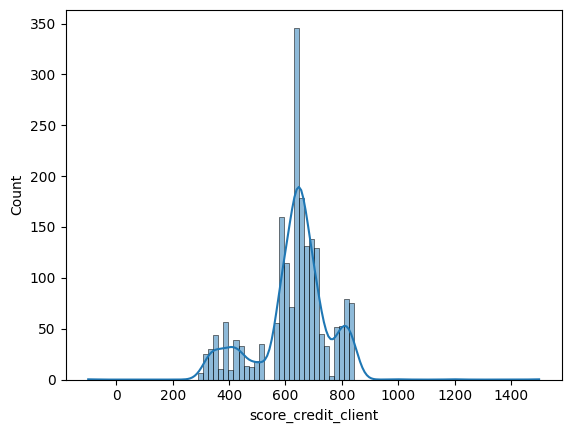

In [129]:
###Méthode1
import seaborn as sns
sns.histplot(df["score_credit_client"],kde=True)
###Méthode2
df["score_credit_client"].skew()

np.float64(-3.630497025419702)

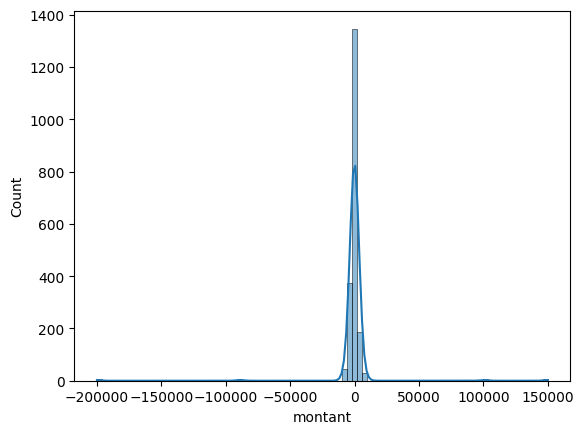

In [130]:
###Méthode1
sns.histplot(df["montant"],kde=True)
###Méthode2
df["montant"].skew()

### Détection anomalies avec IQR(montant )

In [131]:

# Montant
Q1 = df['montant'].quantile(0.25)
Q3 = df['montant'].quantile(0.75)
IQR = Q3 - Q1
min = Q1 - 1.5 * IQR
max = Q3 + 1.5 * IQR



# Flag anomalies
is_anomaly= (
    (df['montant'] < min) | (df['montant'] > max) 
    
)

print("Nombre anomalies détectées :", is_anomaly.sum())


Nombre anomalies détectées : 108


###  Détection des anomalies avec Z-score(score credit client)

In [132]:
import numpy as np
from scipy import stats

# Seuil Z-score
seuil = 3

# Calcul du Z-score pour score_credit_client
z_score_credit = np.abs(stats.zscore(df['score_credit_client'], nan_policy='omit')) # nan_policy='omit' => ignore les valeurs manquantes

# Création du flag 'is_anomaly_Z
is_anomaly_score = (
    (z_score_credit > seuil) |
    (df['score_credit_client'] < 0) |
    (df['score_credit_client'] > 850)
)

# Affichage du nombre d'anomalies
print("Nombre d'anomalies détectées (Z-score) :", is_anomaly_score.sum())


Nombre d'anomalies détectées (Z-score) : 4


### Créer une colonne is_anomaly (booléen) pour marquer les lignes aberrantes

In [133]:
df["is_anomaly"]=(is_anomaly | is_anomaly_score)
print(df["is_anomaly"])

0       False
1       False
2       False
3       False
4       False
        ...  
2054     True
2056    False
2057    False
2058    False
2059    False
Name: is_anomaly, Length: 2000, dtype: bool


#  ₦ Feature Engineering

### Extraire depuis date_transaction : annee, mois, trimestre, jour-semaine

In [134]:
df['date_transaction']=pd.to_datetime(df['date_transaction'],errors='coerce')
df['annee']=df['date_transaction'].dt.year
df['mois']=df['date_transaction'].dt.month
df['trimestre']=df['date_transaction'].dt.quarter
df['jour-semaine']=df['date_transaction'].dt.dayofweek
df.head(3)

,transaction_id,client_id,date_transaction,montant,devise,taux_change_eur,montant_eur,categorie,produit,agence,...,statut,score_credit_client,segment_client,solde_avant,taux_interet,is_anomaly,annee,mois,trimestre,jour-semaine
0,TXN000559,CLI0060,2022-04-19 02:31:00,2050.42,EUR,1.00,2050.42,Depot especes,Compte Epargne,Marseille-Vieux-Port,...,Complete,645.0,Premium,16415.10,NaN,False,2022,4,2,1
1,TXN001154,CLI0057,2024-06-20 20:51:00,-123.66,GBP,0.86,-143.79,Retrait DAB,Credit Consommation,Bordeaux-Meriadeck,...,Rejete,435.0,Risque,42890.81,NaN,False,2024,6,2,3
2,TXN000764,CLI0015,2024-08-28 05:03:00,-396.17,EUR,1.00,-396.17,Prelevement,PEA,Lyon-Part-Dieu,...,Complete,648.0,Standard,48489.38,NaN,False,2024,8,3,2


### Calculer montant_eur_verifie

In [135]:
montant_eur_verifie=df['montant']/df['taux_change_eur']
print("Verification des montant est: \n",montant_eur_verifie)

Verification des montant est: 
 0       2050.420000
1       -143.790698
2       -396.170000
3        225.200000
4        935.320000
           ...     
2054   -5814.400000
2056     296.960000
2057   -2106.580000
2058    -364.680412
2059   -2296.518519
Length: 2000, dtype: float64


### Créer categorie_risque basée sur score_credit_client 

In [136]:
def  categorie_risque(score):
    if score>=700:
        return "Low"
    elif score>=580 :
        return  "Medium"
    else:
        return "High"
    
df['categorie_risque']=df['score_credit_client'].apply(categorie_risque)

# Vérification
df[['score_credit_client', 'categorie_risque']].head()
    

,score_credit_client,categorie_risque
0,645.0,Medium
1,435.0,High
2,648.0,Medium
3,704.0,Low
4,457.0,High


### Calculer solde_net par client : total crédits – total débits

In [137]:
# Solde net par client
solde_net= df.groupby('client_id').apply(lambda x: x.loc[x["type_operation"]=="Credit","montant"].sum()-x.loc[x["type_operation"]=="Debit","montant"].sum())

solde_net

client_id
CLI0001    23886.54
CLI0002    13138.46
CLI0003    20457.45
CLI0004    15621.52
CLI0005    13259.31
             ...   
CLI0146    14791.59
CLI0147    19107.75
CLI0148    19508.75
CLI0149     6825.35
CLI0150     9894.40
Length: 150, dtype: float64

### Agréger par client : nb_transactions, montant_moyen, nb_produits_distincts

In [138]:
agg_client = df.groupby('client_id').agg(
    nb_transactions=('transaction_id', 'count'),
    montant_moyen=('montant', 'mean'),
    nb_produits_distincts=('produit', 'nunique')
).reset_index()

agg_client.head()

,client_id,nb_transactions,montant_moyen,nb_produits_distincts
0,CLI0001,14,108.324286,6
1,CLI0002,12,-403.411667,6
2,CLI0003,13,-777.826923,7
3,CLI0004,16,-94.131250,7
4,CLI0005,9,-708.276667,6


### Créer taux_rejet : proportion de transactions rejetées par agence

In [139]:
df['taux_rejet'] = df.groupby('agence')['statut'].transform(
    lambda x: (x.str.lower() == 'rejete').mean()
).round(3)
df.head()

,transaction_id,client_id,date_transaction,montant,devise,taux_change_eur,montant_eur,categorie,produit,agence,...,segment_client,solde_avant,taux_interet,is_anomaly,annee,mois,trimestre,jour-semaine,categorie_risque,taux_rejet
0,TXN000559,CLI0060,2022-04-19 02:31:00,2050.42,EUR,1.00,2050.42,Depot especes,Compte Epargne,Marseille-Vieux-Port,...,Premium,16415.10,NaN,False,2022,4,2,1,Medium,0.056
1,TXN001154,CLI0057,2024-06-20 20:51:00,-123.66,GBP,0.86,-143.79,Retrait DAB,Credit Consommation,Bordeaux-Meriadeck,...,Risque,42890.81,NaN,False,2024,6,2,3,High,0.046
2,TXN000764,CLI0015,2024-08-28 05:03:00,-396.17,EUR,1.00,-396.17,Prelevement,PEA,Lyon-Part-Dieu,...,Standard,48489.38,NaN,False,2024,8,3,2,Medium,0.040
3,TXN001598,CLI0045,2024-01-07 08:16:00,225.20,EUR,1.00,225.20,Paiement CB,Credit Consommation,Bordeaux-Meriadeck,...,Standard,43962.51,NaN,False,2024,1,1,6,Low,0.046
4,TXN001873,CLI0034,2024-08-11 19:52:00,935.32,EUR,1.00,935.32,Interets,Credit Immobilier,Bordeaux-Meriadeck,...,Risque,17312.83,NaN,False,2024,8,3,6,High,0.046


#  ✓ ₦ Export

In [140]:
# Nombre de valeurs manquantes par colonne
missing_counts = df.isna().sum()
print("Valeurs manquantes par colonne :\n", missing_counts)

# Pourcentage de valeurs manquantes
missing_percent = df.isna().mean() * 100
print("------------------------")
print("Pourcentage de valeurs manquantes par colonne :\n", missing_percent)

Valeurs manquantes par colonne :
 transaction_id            0
client_id                 0
date_transaction          0
montant                   0
devise                    0
taux_change_eur           0
montant_eur               0
categorie                 0
produit                   0
agence                    0
type_operation            0
statut                    0
score_credit_client       0
segment_client            0
solde_avant               0
taux_interet           2000
is_anomaly                0
annee                     0
mois                      0
trimestre                 0
jour-semaine              0
categorie_risque          0
taux_rejet                0
dtype: int64
------------------------
Pourcentage de valeurs manquantes par colonne :
 transaction_id           0.0
client_id                0.0
date_transaction         0.0
montant                  0.0
devise                   0.0
taux_change_eur          0.0
montant_eur              0.0
categorie                0.0
pro

### Exporter le dataset propre et enrichi : financecore_clean.csv

In [141]:
df.to_csv("financecore_clean.csv", index=False)
print("Dataset exporté avec succès sous financecore_clean.csv")

Dataset exporté avec succès sous financecore_clean.csv


In [142]:
decisions = """
# DECISIONS DE NETTOYAGE

## 1. Doublons
- Suppression basée sur transaction_id
- Conservation de la première occurrence

## 2. Types
- date_transaction convertie en datetime
- montant et solde_avant convertis en float

## 3. Valeurs manquantes
- Numériques : imputation par médiane
- Catégorielles : imputation par mode

## 4. Valeurs aberrantes
- Détection via IQR
- Conservation avec flag is_anomaly
- Pas de suppression pour éviter perte d'information

## 5. Normalisation
- devise → uppercase
- segment_client → format uniforme
- nettoyage des espaces

## 6. Feature engineering
- Variables temporelles
- Score de risque client
- Agrégations par client
- Taux de rejet par agence
"""
with open("DECISIONS.md", "w", encoding="utf-8") as f:
    f.write(decisions)
print("DECISIONS.md créé.")

DECISIONS.md créé.
